Dataset Shape: (1048575, 18)
Columns: ['Date received', 'Product', 'Sub-product', 'Issue', 'Sub-issue', 'Consumer complaint narrative', 'Company public response', 'Company', 'State', 'ZIP code', 'Tags', 'Consumer consent provided?', 'Submitted via', 'Date sent to company', 'Company response to consumer', 'Timely response?', 'Consumer disputed?', 'Complaint ID']
Filtered dataset shape: (109303, 3)
Product
Credit reporting, credit repair services, or other personal consumer reports    66042
Debt collection                                                                 30964
Mortgage                                                                        11493
Consumer Loan                                                                     804
Name: count, dtype: int64
TF-IDF shape: (87442, 5000)
Naive Bayes
Accuracy: 0.84
Weighted F1-score: 0.839
              precision    recall  f1-score   support

           0       0.91      0.86      0.89     13208
           1       0.79      0.77

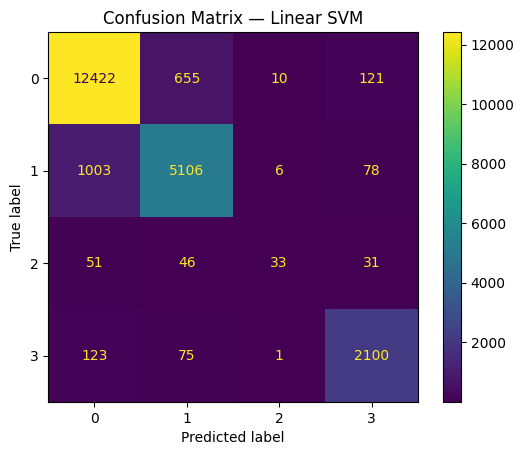


Complaint: My credit report has wrong personal information and needs to be corrected.
Predicted Category → Credit reporting, credit repair services, or other personal consumer reports

Complaint: A debt collector keeps calling me even after payment was made.
Predicted Category → Debt collection

Complaint: My consumer loan application was mishandled — the bank keeps deducting EMI even after the loan was closed and repayment confirmation was sent.
Predicted Category → Credit reporting, credit repair services, or other personal consumer reports

Complaint: My mortgage account payment was not updated by the bank correctly.
Predicted Category → Mortgage


In [8]:
import pandas as pd
import numpy as np
import re
import random
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay
Seed = 42
np.random.seed(Seed)
random.seed(Seed)
df = pd.read_csv("/content/complaints.csv", encoding='ISO-8859-1', engine='python', on_bad_lines='skip')
print("Dataset Shape:", df.shape)
print("Columns:", df.columns.tolist())
df = df[['Product', 'Consumer complaint narrative']].dropna()
label_map = {
    "Credit reporting, credit repair services, or other personal consumer reports": 0,
    "Debt collection": 1,
    "Consumer Loan": 2,
    "Mortgage": 3
}
df = df[df['Product'].isin(label_map.keys())]
df['label'] = df['Product'].map(label_map)
print("Filtered dataset shape:", df.shape)
print(df['Product'].value_counts())
def clean_text(text):
    text = re.sub(r'[^a-zA-Z]', ' ', str(text).lower())
    return re.sub(r'\s+', ' ', text).strip()
df['cleaned'] = df['Consumer complaint narrative'].apply(clean_text)
X_train, X_test, y_train, y_test = train_test_split(
    df['cleaned'], df['label'], test_size=0.2, random_state=Seed, stratify=df['label']
)
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)
print("TF-IDF shape:", X_train_tfidf.shape)
models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=Seed),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=Seed),
    "Linear SVM": LinearSVC(random_state=Seed)
}
results = []
for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    pred = model.predict(X_test_tfidf)
    acc = accuracy_score(y_test, pred)
    f1 = f1_score(y_test, pred, average='weighted')
    results.append((name, acc, f1))
    print(f"{name}")
    print("Accuracy:", round(acc, 3))
    print("Weighted F1-score:", round(f1, 3))
    print(classification_report(y_test, pred, zero_division=0))
result_df = pd.DataFrame(results, columns=['Model', 'Accuracy', 'F1'])
print("Model Comparison:\n", result_df)
best_model_name = result_df.loc[result_df['F1'].idxmax(), 'Model']
best_model = models[best_model_name]
best_model.fit(X_train_tfidf, y_train)
final_pred = best_model.predict(X_test_tfidf)
print("Best Model:", best_model_name)
print(classification_report(y_test, final_pred, zero_division=0))
ConfusionMatrixDisplay.from_estimator(best_model, X_test_tfidf, y_test)
plt.title(f"Confusion Matrix — {best_model_name}")
plt.show()
samples = [
    "My credit report has wrong personal information and needs to be corrected.",
    "A debt collector keeps calling me even after payment was made.",
    "My consumer loan application was mishandled — the bank keeps deducting EMI even after the loan was closed and repayment confirmation was sent.",
    "My mortgage account payment was not updated by the bank correctly."
]
for text in samples:
    sample_vec = tfidf.transform([text])
    pred = best_model.predict(sample_vec)[0]
    for k, v in label_map.items():
        if v == pred:
            print(f"\nComplaint: {text}")
            print(f"Predicted Category → {k}")
